In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import bin2cell as b2c
print(b2c.__version__)

bioimageio_utils.py (2): pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


0.3.3


In [2]:
# import session_info
# session_info.show()

# Read the objects

In [3]:
adata_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/CellTalkHHD/VisiumHD/bin2cell_objects'
!ls {adata_dir}

archive_coarse_grain_subsets
CellTalkHHD_Human_10_BRC2770-2772-10_b2c_2um-bins.h5ad
CellTalkHHD_Human_10_BRC2770-2772-10_b2c_cells.h5ad
CellTalkHHD_Human_11_BRC2727-13_b2c_2um-bins.h5ad
CellTalkHHD_Human_11_BRC2727-13_b2c_cells.h5ad
CellTalkHHD_Human_1_2733_09-20_A1_b2c_2um-bins.h5ad
CellTalkHHD_Human_1_2733_09-20_A1_b2c_cells.h5ad
CellTalkHHD_Human_12_BRC2779-10_b2c_2um-bins.h5ad
CellTalkHHD_Human_12_BRC2779-10_b2c_cells.h5ad
CellTalkHHD_Human_13_BRC2757-2758-7_b2c_2um-bins.h5ad
CellTalkHHD_Human_13_BRC2757-2758-7_b2c_cells.h5ad
CellTalkHHD_Human_14_BRC2773-2775-11_b2c_2um-bins.h5ad
CellTalkHHD_Human_14_BRC2773-2775-11_b2c_cells.h5ad
CellTalkHHD_Human_17_BRC2794-13-A1_b2c_2um-bins.h5ad
CellTalkHHD_Human_17_BRC2794-13-A1_b2c_cells.h5ad
CellTalkHHD_Human_18_BRC2792-2-D1_b2c_2um-bins.h5ad
CellTalkHHD_Human_18_BRC2792-2-D1_b2c_cells.h5ad
CellTalkHHD_Human_2_2733_09-20_D1_b2c_2um-bins.h5ad
CellTalkHHD_Human_2_2733_09-20_D1_b2c_cells.h5ad
CellTalkHHD_Human_3_2733_25-28_A1_b2c_2um-bins.h5ad


In [4]:
sample_id = 'HEA_FOET14880396'

In [5]:
adata = sc.read_h5ad(f'{adata_dir}/{sample_id}_b2c_2um-bins.h5ad') # read 2um object which has b2c cell grouping
cdata = sc.read_h5ad(f'{adata_dir}/{sample_id}_b2c_cells.h5ad') # read b2c object
anno_df = pd.read_csv('./loupe_annotations/HistologicalAnnotation_C194.csv',index_col=0)
anno = 'HistologicalAnnotation'
cell_grouping = 'labels_joint'

# Import annotations from loupe browser

In [6]:
def map_loupe_to_b2c(
        adata,
        cdata,
        anno_df,
        anno,
        cell_grouping = 'labels_he_expanded', 
        ):
     

    # Calculate the binned row and column indices in adata
    adata.obs['binned_8_row'] = adata.obs['array_row'] // 4
    adata.obs['binned_8_col'] = adata.obs['array_col'] // 4

    # Create a combined index in adata and set it as the index
    adata.obs['mapping_index_08'] = 's_008um_' + adata.obs['binned_8_row'].astype(str).str.zfill(5) + '_' + adata.obs['binned_8_col'].astype(str).str.zfill(5) + '-1'
    adata.obs['mapping_index_08'].value_counts() # most should have 16 but there are some on the tissue edge that actually have less due to partial overlap 

    # read annotations from df and map to the 2um object 
    print('annotations to map:')
    print(anno_df.head(5))
    mapping_dict = pd.Series(anno_df[anno].values,index=anno_df.index).to_dict()
    adata.obs[anno] = adata.obs['mapping_index_08'].map(mapping_dict) # update 2um object 

    # assign annotation to cells by pandas.Series.mode(). The mode is the value that appears most often which captures the most frequent annotation for that cell from 2um data
    filtered_data = adata.obs[(adata.obs[cell_grouping] != 0) & adata.obs[anno].notna()]
    cell_annotation = (
        filtered_data.groupby(cell_grouping)[anno]
        .apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    )
    cell_annotation.index = cell_annotation.index.astype('str')
    cdata.obs[anno] = cdata.obs.index.map(cell_annotation).astype('category') # label cells 
    print('Annotations in b2c object:')
    print(cdata.obs[anno].value_counts())

map_loupe_to_b2c(adata,
                 cdata,
                 anno_df,
                 anno,
                 cell_grouping)

annotations to map:
                                      HistologicalAnnotation
Barcode                                                     
s_008um_00301_00321-1                                 Valves
s_008um_00602_00290-1  Great vessel - Pulmonary artery Right
s_008um_00377_00750-1                      Ventricle - outer
s_008um_00383_00696-1                      Ventricle - inner
s_008um_00526_00291-1                   Great vessel - Aorta
Annotations in b2c object:
HistologicalAnnotation
Ventricle - outer                                             73280
Connective tissue                                             28255
Atrium - right                                                14453
Ventricle - inner                                             12052
Valves                                                         7356
Atrium - left                                                  6272
non-cardiac tissue                                             5409
Great vessel - Pulmonary ar

# Plot

In [7]:
annotations_to_plot = list(set(anno_df['HistologicalAnnotation'].dropna()))
group_col = 'HistologicalAnnotation'
len(annotations_to_plot)

11

1853801764.py (1): Use `squidpy.pl.spatial_scatter` instead.


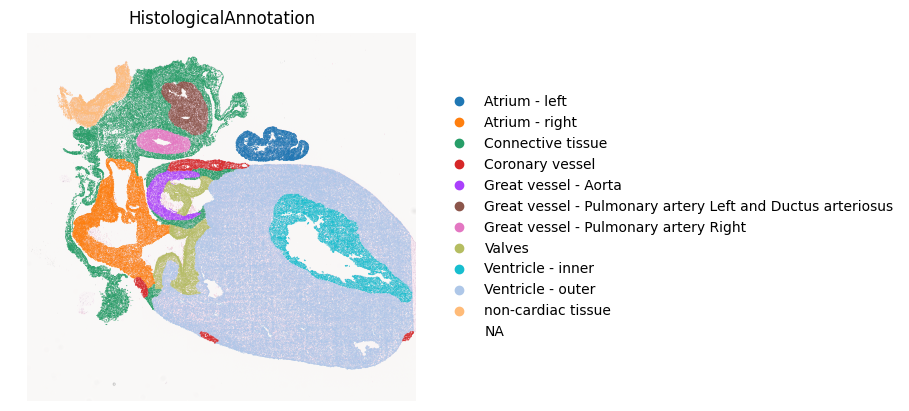

In [8]:
sc.pl.spatial(cdata, 
                  color=group_col, 
                  img_key="0.3_mpp_150_buffer", basis="spatial_cropped_150_buffer",
                  size=1.5,alpha_img=0.3,
                  frameon=False,
                 )

# Save annotation

In [11]:
cdata.obs.to_csv(f'./mapped_loupe_annotations/{sample_id}_HistologicalAnnotation_mapped-obs.csv')
cdata.obs.head()

,object_id,bin_count,array_row,array_col,labels_joint_source,in_tissue_manual,HistologicalAnnotation
1,1,31,2932.612903,334.000000,primary,tissue,non-cardiac tissue
2,2,26,2959.346154,336.923077,primary,tissue,non-cardiac tissue
3,3,32,2882.562500,334.187500,primary,tissue,non-cardiac tissue
4,4,28,2862.250000,515.178571,primary,tissue,non-cardiac tissue
5,5,35,2870.714286,305.171429,primary,tissue,non-cardiac tissue
